In [12]:
import json
import pandas as pd
from io import StringIO

with open('../data/highest_result.json', 'r') as file:
    data = json.load(file)

activities_str = data['activitiesLog']

df = pd.read_csv(StringIO(activities_str), sep=';')

df

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,TOMATOES,4999,6,4998,19,NaN,NaN,5013,6,5014,19,NaN,NaN,5006.0,0.000000
1,-1,0,EMERALDS,9992,15,9990,30,NaN,NaN,10008,15,10010,30,NaN,NaN,10000.0,0.000000
2,-1,100,EMERALDS,9992,13,9990,30,NaN,NaN,10008,13,10010,30,NaN,NaN,10000.0,0.000000
3,-1,100,TOMATOES,5000,5,4998,23,NaN,NaN,5013,5,5014,23,NaN,NaN,5006.5,0.000000
4,-1,200,EMERALDS,9992,13,9990,21,NaN,NaN,10008,13,10010,21,NaN,NaN,10000.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,-1,199700,EMERALDS,9992,14,9990,28,NaN,NaN,10008,14,10010,28,NaN,NaN,10000.0,984.000000
3996,-1,199800,EMERALDS,9992,15,9990,27,NaN,NaN,10008,15,10010,27,NaN,NaN,10000.0,984.000000
3997,-1,199800,TOMATOES,4989,8,4987,25,NaN,NaN,5002,8,5003,25,NaN,NaN,4995.5,1315.808594
3998,-1,199900,TOMATOES,4990,10,4989,15,NaN,NaN,5003,10,5005,15,NaN,NaN,4996.5,1330.296875


In [20]:
import json
from io import StringIO
from pathlib import Path

import pandas as pd


def load_highest_result_log(path="../data/highest_result.log"):
    path = Path(path)

    with path.open("r", encoding="utf-8") as f:
        raw = json.load(f)

    # Parse the semicolon-delimited activities table embedded as a string
    activities = pd.read_csv(
        StringIO(raw["activitiesLog"]),
        sep=";",
        na_values=["", "null", "None"],
    )

    # Convert numeric columns where possible
    for col in activities.columns:
        activities[col] = pd.to_numeric(activities[col], errors="ignore")

    # Parse trade history
    trades = pd.DataFrame(raw.get("tradeHistory", []))
    for col in trades.columns:
        trades[col] = pd.to_numeric(trades[col], errors="ignore")

    # Parse sandbox logs if you want them too
    sandbox = pd.DataFrame(raw.get("sandboxLogs", []))
    for col in sandbox.columns:
        sandbox[col] = pd.to_numeric(sandbox[col], errors="ignore")

    return {
        "submission_id": raw.get("submissionId"),
        "activities": activities,
        "trades": trades,
        "sandbox": sandbox,
        "raw": raw,
    }


parsed = load_highest_result_log()

submission_id = parsed["submission_id"]
activities_df = parsed["activities"]
trades_df = parsed["trades"]
sandbox_df = parsed["sandbox"]

print(activities_df.head())
print(trades_df.head())


ValueError: invalid error value specified

In [18]:
df = load_highest_result_log()["activities"]
df.head()

ValueError: invalid error value specified

In [19]:
df.info()
df[df["product"] == "TOMATOES"].head()
df.groupby("product")["profit_and_loss"].max()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   day              4000 non-null   int64  
 1   timestamp        4000 non-null   int64  
 2   product          4000 non-null   str    
 3   bid_price_1      4000 non-null   int64  
 4   bid_volume_1     4000 non-null   int64  
 5   bid_price_2      4000 non-null   int64  
 6   bid_volume_2     4000 non-null   int64  
 7   bid_price_3      88 non-null     float64
 8   bid_volume_3     88 non-null     float64
 9   ask_price_1      4000 non-null   int64  
 10  ask_volume_1     4000 non-null   int64  
 11  ask_price_2      4000 non-null   int64  
 12  ask_volume_2     4000 non-null   int64  
 13  ask_price_3      96 non-null     float64
 14  ask_volume_3     96 non-null     float64
 15  mid_price        4000 non-null   float64
 16  profit_and_loss  4000 non-null   float64
dtypes: float64(6), int64(10),

product
EMERALDS     984.000000
TOMATOES    1330.296875
Name: profit_and_loss, dtype: float64

In [ ]:
df["spread_1"] = df["ask_price_1"] - df["bid_price_1"]
df.head(2)

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,spread_1
0,-1,0,TOMATOES,4999,6,4998,19,NaN,NaN,5013,6,5014,19,NaN,NaN,5006.0,0.0,14
1,-1,0,EMERALDS,9992,15,9990,30,NaN,NaN,10008,15,10010,30,NaN,NaN,10000.0,0.0,16


In [ ]:
product_results_eme = df[df['product']=='EMERALDS']
product_results_tom = df[df['product']=='TOMATOES']

In [ ]:
import matplotlib.pyplot as plt

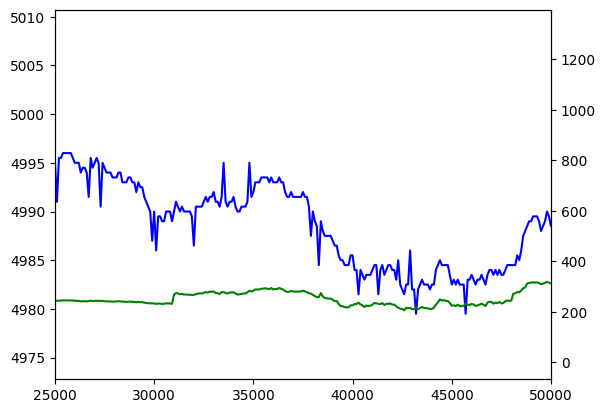

In [ ]:
x_val = product_results_eme["timestamp"]
y1_vals = (product_results_tom["mid_price"])
y2_vals = (product_results_tom["profit_and_loss"])

fig, ax1 = plt.subplots()
plt.plot(x_val, y1_vals, 'b', lw=1.5, label='1st')
ax1.set_xlim(25000, 50000)
#plt.plot(y1_vals, 'ro')
#plt.legend(loc=8)

ax2 = ax1.twinx()
plt.plot(x_val, y2_vals, 'g', lw=1.5, label='2nd')
#plt.plot(y2_vals, 'ro')
#plt.legend(loc=0)

plt.show()

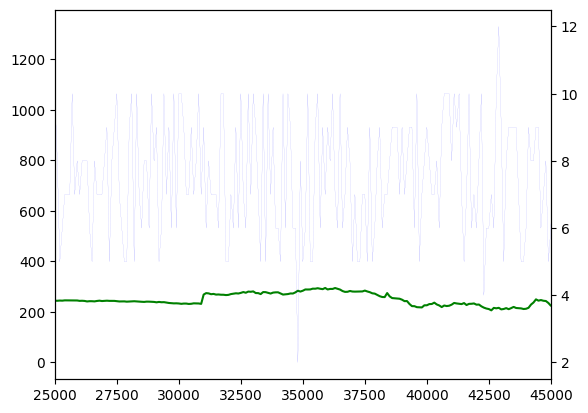

In [ ]:
x = product_results_eme["timestamp"]
y1 = product_results_tom['profit_and_loss']
y2 = product_results_tom['bid_volume_1']

fig, ax1 = plt.subplots()
plt.plot(x, y1, 'g', lw=1.5)
ax1.set_xlim(25000, 45000)

ax2 = ax1.twinx()
plt.plot(x, y2, 'b', lw=.05)

plt.show()


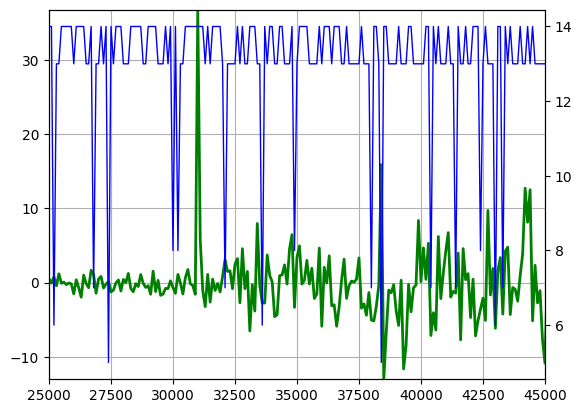

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = product_results_eme["timestamp"].to_numpy()
y1 = product_results_tom["profit_and_loss"].diff().to_numpy()
y2 = product_results_tom["spread_1"].shift(1).to_numpy()

start = 25000
end = 45000

mask = (x >= start) & (x <= end)
y1_zoom = y1[mask]

fig, ax1 = plt.subplots()

ax1.plot(x, y1, 'g', lw=2, zorder=3)
ax1.set_xlim(start, end)
ax1.set_ylim(y1_zoom.min(), y1_zoom.max())

ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(x, y2, 'b', lw=1, zorder=1)

plt.show()

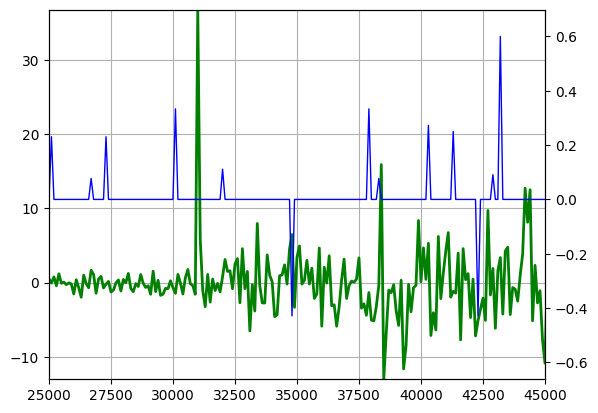

In [ ]:
product_results_tom['lev_1_vol'] = (product_results_tom['bid_volume_1'] + 
                                    product_results_tom['ask_volume_1'])
product_results_tom['order_regime'] = ((product_results_tom['bid_volume_1'] - 
                                       product_results_tom['ask_volume_1']) /
                                       (product_results_tom['bid_volume_1'] +
                                       product_results_tom['ask_volume_1']))

x = product_results_eme["timestamp"].to_numpy()
y1 = product_results_tom["profit_and_loss"].diff().to_numpy()
y2 = product_results_tom['order_regime'].to_numpy()

start = 25000
end = 45000

mask = (x >= start) & (x <= end)
y1_zoom = y1[mask]

fig, ax1 = plt.subplots()

ax1.plot(x, y1, 'g', lw=2, zorder=3)
ax1.set_xlim(start, end)
ax1.set_ylim(y1_zoom.min(), y1_zoom.max())

ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(x, y2, 'b', lw=1, zorder=1)

plt.show()

In [ ]:
corr = product_results_tom['order_regime'].shift(1).corr(product_results_tom['mid_price'].diff())
print(corr)

0.2669925457523248


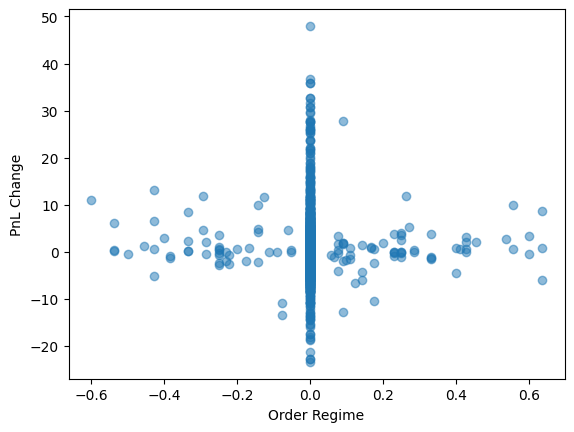

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(product_results_tom['order_regime'], product_results_tom['profit_and_loss'].diff(), alpha=.5)
plt.xlabel("Order Regime")
plt.ylabel("PnL Change")
plt.show()